In [1]:
import os
import yaml

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib
from matplotlib import pyplot as plt

In [2]:
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [3]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

In [ ]:
LOG_DIR = '/path/to/project/root/IterativeImaging/logs_official/runs'

In [5]:
FLOPS_PER_INFER = 12443713536

In [ ]:
dfs = []

for root, dirs, files in os.walk(LOG_DIR):
    for file in files:
        if '.csv' in file:
            # print(root)
            with open(os.path.join(root, 'hparams.yaml')) as f:
                hparams = yaml.load(f, Loader=yaml.FullLoader)

            if hparams['seed'] != 0 or hparams['model']['experiment_setting']['noise_ratio'] != 0.01:
                print(f"Skip {root}")
                continue

            print(f"Processing {root}")
            df = pd.read_csv(os.path.join(root, file))

            exp_name = ''
            policy = hparams['model']['frozen_strategy']['name']
            df['policy'] = policy
            exp_name += policy

            N0 = hparams['model']['frozen_strategy']['N0']
            df['N0'] = N0
            exp_name += f'_N0={N0}'

            base = hparams['model']['frozen_strategy'].get('base', np.nan)
            df['base'] = base
            if not np.isnan(base):
                exp_name += f'_base={base}'

            inc = hparams['model']['frozen_strategy'].get('inc', np.nan)
            df['inc'] = inc
            if not np.isnan(inc):
                exp_name += f'_inc={inc}'

            df['exp_name'] = exp_name

            print(df.columns)
            dfs.append(df)

df = pd.concat(dfs)

In [7]:
df.reset_index(drop=True, inplace=True)
df

,epoch,step,train/inference_steps,train/loss,train/sample_buffer_size,train/sampling_cost,train/training_cost,valid/psnr,valid/ssim,policy,N0,base,inc,exp_name,train/recovered_psnr
0,0,49,1600.0,0.088827,160.0,0.0,1600.0,NaN,NaN,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
1,0,99,3200.0,0.081643,160.0,0.0,3200.0,NaN,NaN,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
2,0,149,4800.0,0.080997,160.0,0.0,4800.0,NaN,NaN,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
3,0,199,6400.0,0.079618,160.0,0.0,6400.0,NaN,NaN,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
4,0,249,8000.0,0.078831,160.0,0.0,8000.0,NaN,NaN,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146843,302,566999,187752000.0,0.038682,75.0,18143520.0,6316800.0,NaN,NaN,constant,100,NaN,NaN,constant_N0=100,NaN
146844,302,567049,187763360.0,0.037160,137.0,18144640.0,6316960.0,NaN,NaN,constant,100,NaN,NaN,constant_N0=100,NaN
146845,302,567099,187785760.0,0.036515,50.0,18146848.0,6317280.0,NaN,NaN,constant,100,NaN,NaN,constant_N0=100,NaN
146846,302,567149,187797120.0,0.035869,135.0,18147968.0,6317440.0,NaN,NaN,constant,100,NaN,NaN,constant_N0=100,NaN


In [8]:
# for all rows that 'valid/psnr' is not NaN,
# we fill the previous row with the 'valid/psnr' value
# this is because the 'valid/psnr' is only recorded every 1000 iterations
for idx in df[~df['valid/psnr'].isna()].index:
    df.loc[idx - 1, 'valid/psnr'] = df.loc[idx, 'valid/psnr']
    df.loc[idx - 1, 'valid/ssim'] = df.loc[idx, 'valid/ssim']

In [9]:
df = df[(~df['valid/psnr'].isna()) & (~df['train/loss'].isna())]
df.reset_index(drop=True, inplace=True)
df

,epoch,step,train/inference_steps,train/loss,train/sample_buffer_size,train/sampling_cost,train/training_cost,valid/psnr,valid/ssim,policy,N0,base,inc,exp_name,train/recovered_psnr
0,0,299,9600.0,0.076536,160.0,0.0,9600.0,41.492882,0.997120,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
1,0,599,19200.0,0.070826,160.0,0.0,19200.0,41.884830,0.997759,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
2,0,899,28800.0,0.069835,160.0,0.0,28800.0,42.134869,0.998055,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
3,0,1199,38400.0,0.065051,160.0,0.0,38400.0,42.340736,0.998224,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
4,0,1499,48000.0,0.062867,160.0,0.0,48000.0,42.559494,0.998341,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20246,301,565849,187378720.0,0.036925,67.0,18106720.0,6311520.0,40.702419,0.997027,constant,100,NaN,NaN,constant_N0=100,NaN
20247,301,566149,187471200.0,0.034670,142.0,18115840.0,6312800.0,40.684391,0.997011,constant,100,NaN,NaN,constant_N0=100,NaN
20248,302,566549,187606240.0,0.038557,63.0,18129152.0,6314720.0,40.685234,0.996997,constant,100,NaN,NaN,constant_N0=100,NaN
20249,302,566849,187708160.0,0.038103,160.0,18139200.0,6316160.0,40.690117,0.997011,constant,100,NaN,NaN,constant_N0=100,NaN


In [10]:
df=df.drop(df[(df['train/inference_steps']>1.9e7) & (df['exp_name']=='constant_N0=1')].index)
df=df.drop(df[(df['train/inference_steps']>5.5e7) & (df['exp_name']=='constant_N0=10')].index)


In [11]:
df = df[::5]
df = df[df['train/inference_steps'] < 3e8]
df.reset_index(drop=True, inplace=True)
df

,epoch,step,train/inference_steps,train/loss,train/sample_buffer_size,train/sampling_cost,train/training_cost,valid/psnr,valid/ssim,policy,N0,base,inc,exp_name,train/recovered_psnr
0,0,299,9600.0,0.076536,160.0,0.0,9600.0,41.492882,0.997120,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
1,0,1799,57600.0,0.061644,160.0,0.0,57600.0,42.709156,0.998402,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
2,1,3349,107200.0,0.058927,160.0,0.0,107200.0,43.530464,0.998566,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
3,2,4949,158400.0,0.049538,160.0,0.0,158400.0,44.012798,0.998636,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
4,3,6499,208000.0,0.046757,160.0,0.0,208000.0,44.273048,0.998656,linear,1,NaN,1.0,linear_N0=1_inc=1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3746,298,560249,185559200.0,0.035184,89.0,17927392.0,6285280.0,40.691055,0.997005,constant,100,NaN,NaN,constant_N0=100,NaN
3747,299,561799,186060160.0,0.036259,118.0,17976768.0,6292480.0,40.668087,0.997022,constant,100,NaN,NaN,constant_N0=100,NaN
3748,300,563399,186585280.0,0.036752,41.0,18028512.0,6300160.0,40.717438,0.997054,constant,100,NaN,NaN,constant_N0=100,NaN
3749,301,564949,187084960.0,0.037879,112.0,18077760.0,6307360.0,40.700077,0.997014,constant,100,NaN,NaN,constant_N0=100,NaN


In [12]:
exp_names = df['exp_name'].unique()
for exp_name in exp_names:
    print(exp_name, df[df['exp_name'] == exp_name]['valid/psnr'].max())

linear_N0=1_inc=1.0 45.43916320800781
exponential_N0=1_base=1.2 44.6245231628418
exponential_N0=1000_base=1.05 44.61540603637695
constant_N0=1 42.7237434387207
constant_N0=10 43.16034698486328
constant_N0=1000 45.02302169799805
constant_N0=1000000000 42.187042236328125
linear_N0=1_inc=10.0 44.64446258544922
linear_N0=1_inc=3.0 44.24550247192383
exponential_N0=10_base=1.05 44.36775207519531
exponential_N0=1_base=1.05 44.32526397705078
exponential_N0=1_base=1.1 44.94474792480469
exponential_N0=100_base=1.05 45.01984405517578
constant_N0=100 44.215213775634766


In [13]:
exp_names = [
    'constant_N0=1',
    'constant_N0=10',
    'constant_N0=100',
    'constant_N0=1000',
    # 'constant_N0=1000000000',
    # 'exponential_N0=1_base=1.05',
    # 'exponential_N0=1_base=1.1',
    # 'exponential_N0=1_base=1.2',
    # 'exponential_N0=10_base=1.05',
    'exponential_N0=100_base=1.05',  # **
    # 'exponential_N0=1000_base=1.05',
    # 'exponential_N0=10_base=1.05',
    'linear_N0=1_inc=1.0',
    'linear_N0=1_inc=3.0',
    'linear_N0=1_inc=10.0',
]

In [14]:
flops_scale = 1e18
df['flops'] = FLOPS_PER_INFER * df['train/inference_steps']
df['flops_scaled'] = df['flops'] / flops_scale

In [15]:
reds = ['#FBA7AB', '#D1686E', '#A7383D', '#FBA7AB', '#7D151A']
reds = ['#601002', '#7B2A1A', '#B45C46', '#FFAC91', '#FFCCB1']
reds = ["#f19f79", "#ec8269", "#e66459", "#e04749", "#da2938"]
# https://coolors.co/f19f79-ec8269-e66459-e04749-da2938
greens = ['#CEEC9D', '#9FC462', '#759D34', '#507614', '#314F00']
greens = ["#abdf93", "#87c27e", "#63a568", "#3f8853", "#1a6a3d"]
# https://coolors.co/abdf93-87c27e-63a568-3f8853-1a6a3d
blues = ['#8180B2', '#565595', '#353377', '#1B1A59', '#0A093B']
blues = ["#7abaf2", "#689dd4", "#567fb6", "#446198", "#314379"]
# https://coolors.co/7abaf2-689dd4-567fb6-446198-314379
constant_color = [greens[k] for k in [0, 2, 3, 4]]
linear_color = [blues[k] for k in [0, 2, 4]]
exp_color = [reds[k] for k in [0, 1, 2, 3, 4,]]
exp_color = [reds[k] for k in [4,]]

constant_palette = sns.color_palette(constant_color)
linear_palette = sns.color_palette(linear_color)
exp_palette = sns.color_palette(exp_color)

[<matplotlib.lines.Line2D object at 0x7f4650155dd0>, <matplotlib.lines.Line2D object at 0x7f465015e810>, <matplotlib.lines.Line2D object at 0x7f46501571d0>, <matplotlib.lines.Line2D object at 0x7f4650152990>, <matplotlib.lines.Line2D object at 0x7f4650169450>, <matplotlib.lines.Line2D object at 0x7f4650966750>, <matplotlib.lines.Line2D object at 0x7f46509659d0>, <matplotlib.lines.Line2D object at 0x7f465096d710>]
['constant_N0=1', 'constant_N0=10', 'constant_N0=100', 'constant_N0=1000', 'linear_N0=1_inc=1.0', 'linear_N0=1_inc=3.0', 'linear_N0=1_inc=10.0', 'exponential_N0=100_base=1.05']


/tmp/ipykernel_2074751/2260833976.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'constant'].sort_values('N0'),
/tmp/ipykernel_2074751/2260833976.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'linear'].sort_values('inc'),
/tmp/ipykernel_2074751/2260833976.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'exponential'].sort_values('N0'),


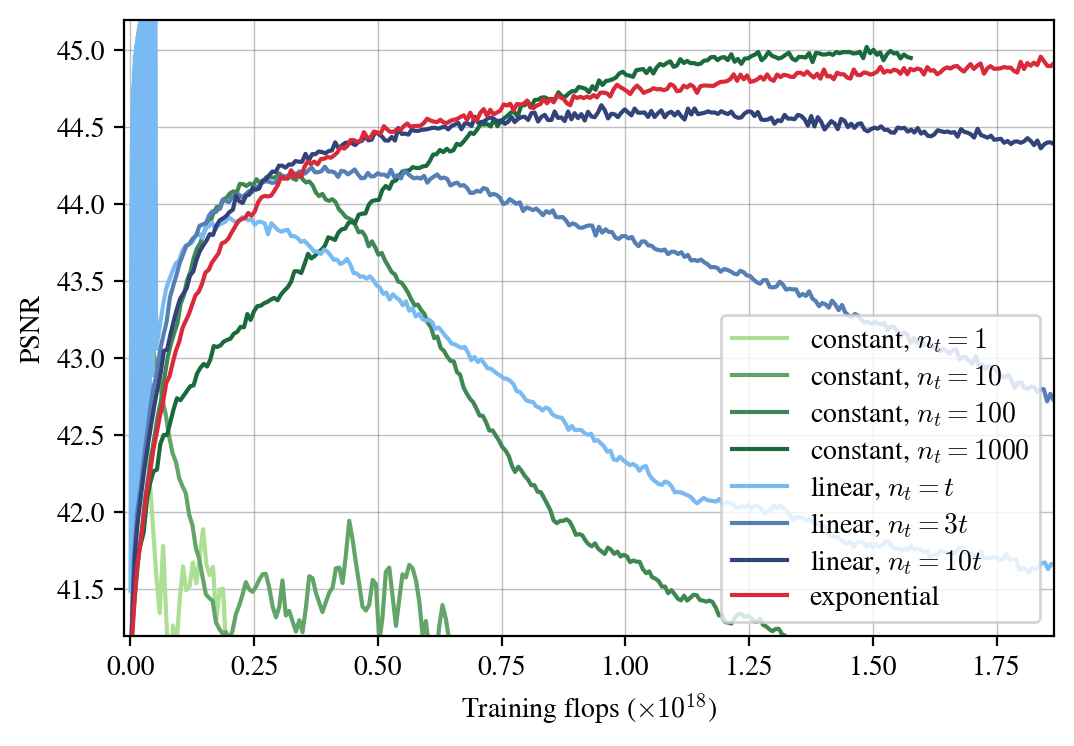

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'constant'].sort_values('N0'),
                  x='flops_scaled', y='valid/psnr', hue='exp_name', palette=constant_palette,
                  markers=True, dashes=False)
ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'linear'].sort_values('inc'),
                  x='flops_scaled', y='valid/psnr', hue='exp_name', palette=linear_palette,
                  markers=True, dashes=False)
ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'exponential'].sort_values('N0'),
                  x='flops_scaled', y='valid/psnr', hue='exp_name', palette=exp_palette,
                  markers=True, dashes=False)
ax.set_xlabel(r'Training flops ($\times10^{18}$)')
ax.set_ylabel('PSNR')
ax.set_ylim(41.2, 45.2)
ax.set_xlim(-1e6 * FLOPS_PER_INFER / flops_scale, 1.5e8 * FLOPS_PER_INFER / flops_scale)
# ax.set_xscale('log')
ax.grid(True, which='major', axis='x', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)
ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)

handles, labels = ax.get_legend_handles_labels()
print(handles)
print(labels)

label_map = {
    'constant_N0=1': r'constant, $n_t=1$',
    'constant_N0=10': r'constant, $n_t=10$',
    'constant_N0=100': r'constant, $n_t=100$',
    'constant_N0=1000': r'constant, $n_t=1000$',
    'linear_N0=1_inc=1.0': r'linear, $n_t=t$',
    'linear_N0=1_inc=3.0': r'linear, $n_t=3t$',
    'linear_N0=1_inc=10.0': r'linear, $n_t=10t$',
    'exponential_N0=100_base=1.05': r'exponential',
}
labels = [label_map[label] for label in labels]

ax.legend(handles=handles, labels=labels, loc='lower right', labelspacing=.3, prop={'size': 10})


# plt.savefig('noise_ratio=0.01.pdf', dpi=300)
# ax.hlines(41.15, -5e6, 3.2e8, colors='r', linestyles='dashed', label='SFT w/ ground truth')
# ax.hlines(36.97, -5e6, 3.2e8, colors='k', linestyles='dashed', label='No SFT')

/tmp/ipykernel_2074751/315428106.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'constant'].sort_values('N0'),
/tmp/ipykernel_2074751/315428106.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'linear'].sort_values('inc'),
/tmp/ipykernel_2074751/315428106.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'exponential'].sort_values('N0'),


[<matplotlib.lines.Line2D object at 0x7f465096f490>, <matplotlib.lines.Line2D object at 0x7f4650837cd0>, <matplotlib.lines.Line2D object at 0x7f4650838710>, <matplotlib.lines.Line2D object at 0x7f4650838fd0>, <matplotlib.lines.Line2D object at 0x7f4650222150>, <matplotlib.lines.Line2D object at 0x7f465084ee10>, <matplotlib.lines.Line2D object at 0x7f465085f750>, <matplotlib.lines.Line2D object at 0x7f4650222590>]
['constant_N0=1', 'constant_N0=10', 'constant_N0=100', 'constant_N0=1000', 'linear_N0=1_inc=1.0', 'linear_N0=1_inc=3.0', 'linear_N0=1_inc=10.0', 'exponential_N0=100_base=1.05']


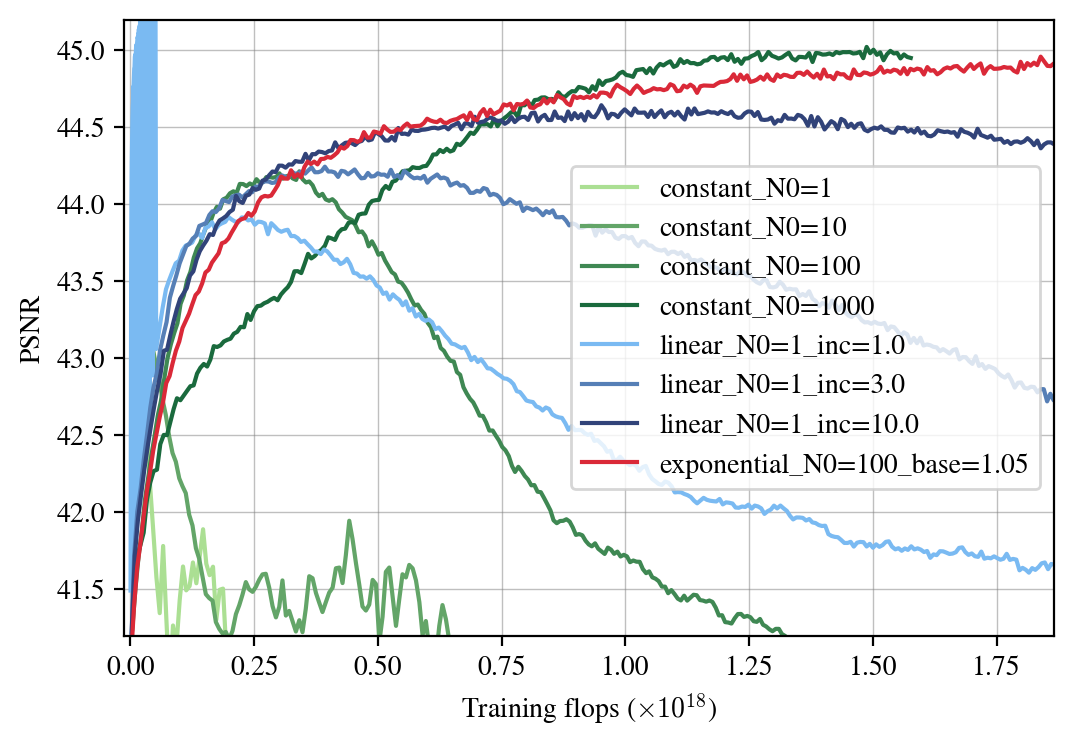

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))

ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'constant'].sort_values('N0'),
                  x='flops_scaled', y='valid/psnr', hue='exp_name', palette=constant_palette,
                  markers=True, dashes=False)
ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'linear'].sort_values('inc'),
                  x='flops_scaled', y='valid/psnr', hue='exp_name', palette=linear_palette,
                  markers=True, dashes=False)
ax = sns.lineplot(data=df[df['exp_name'].isin(exp_names)][df['policy'] == 'exponential'].sort_values('N0'),
                  x='flops_scaled', y='valid/psnr', hue='exp_name', palette=exp_palette,
                  markers=True, dashes=False)
ax.set_xlabel(r'Training flops ($\times10^{18}$)')
ax.set_ylabel('PSNR')
ax.set_ylim(41.2, 45.2)
ax.set_xlim(-1e6 * FLOPS_PER_INFER / flops_scale, 1.5e8 * FLOPS_PER_INFER / flops_scale)
# ax.set_xscale('log')
ax.grid(True, which='major', axis='x', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)
ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels)
print(handles)
print(labels)

# plt.savefig('noise_ratio=0.01.pdf', dpi=300)
# ax.hlines(41.15, -5e6, 3.2e8, colors='r', linestyles='dashed', label='SFT w/ ground truth')
# ax.hlines(36.97, -5e6, 3.2e8, colors='k', linestyles='dashed', label='No SFT')